# Statistical Analysis of Player Behavior and Motivation in Gameplay Telemetry

Udacity AI Masters Capstone - Project 2: Statistical Analysis

**Student:** Robert Mayfield

In [ ]:
import sys
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score

sys.path.insert(0, str(Path('../src')))
from inspection import inspect_dataframe, plot_missing, plot_numeric_distributions
from bias import plot_group_distribution, plot_response_skew, summarize_coverage

DATA_ZIP = Path('../data/raw/data.zip')

In [ ]:
%matplotlib inline

## 1. Project Overview

This project uses gameplay telemetry and player survey data from a longitudinal study conducted within PowerWash Simulator to examine whether intrinsic motivation is associated with session duration.

**Research question:** Do players who report higher enjoyment tend to play in longer sessions?

**Null hypothesis:** Session duration does not differ between high enjoyment and low enjoyment player groups.

**Alternative hypothesis:** Session duration differs between high enjoyment and low enjoyment player groups.

Player enjoyment is measured using survey prompts triggered at regular intervals during gameplay. Each prompt asks the player to rate their enjoyment on a Visual Analogue Scale from 0 to 1000 (Vuorre et al., 2023). Players are assigned to high or low enjoyment groups in Section 3 using a median split of each player's mean enjoyment score across all their recorded responses.

Session duration is measured in minutes using the `CurrentSessionLength` variable recorded at each game exit event. This variable is an integer representing total minutes since the game was launched, rounding down, and resetting to zero when the game is closed.

Dataset loading and initial inspection follow the Initial Data Analysis (IDA) framework, which emphasizes systematic examination of data structure, variable types, and quality before hypothesis testing begins (Lusa et al., 2024).

This project establishes a statistical foundation for how gameplay telemetry signals can support reasoning about player engagement and motivation.

## 2. Dataset Loading and Inspection

The dataset is distributed as a zip archive containing 18 CSV files. This section loads and inspects the five files relevant to this analysis. Three files are excluded: `game_saved.csv` (deprecated in dataset v1.1.0), `subtask_completed.csv` (3.7 GB uncompressed), and `update_current_state.csv` (3.0 GB uncompressed) provide event granularity below the session level that is not needed here.

| File | Contents |
|---|---|
| `demographics.csv` | One row per participant: age, gender, country, login count |
| `study_prompt_answered.csv` | All in-game survey responses across six prompt types |
| `exited_game.csv` | Session exit events including `CurrentSessionLength` |
| `player_logged_in.csv` | Login events per player |
| `job_completed.csv` | Job completion events per player |

In [2]:
with zipfile.ZipFile(DATA_ZIP) as z:
    with z.open('data/demographics.csv') as f:
        demographics = pd.read_csv(f)

inspect_dataframe(demographics)

SHAPE AND STRUCTURE
------------------------------------------------------------
Rows:    11,080
Columns: 9

COLUMN NAMES AND DATA TYPES
------------------------------------------------------------
pid                   str
responses         float64
logins              int64
first_login           str
last_login            str
country               str
age               float64
gender                str
n_demographics      int64

MEMORY USAGE
------------------------------------------------------------
Total: 3.38 MB

MISSING VALUES
------------------------------------------------------------
            Null Count  Null %
last_login        2832   25.56
responses         1038    9.37
country            410    3.70
age                116    1.05
gender              62    0.56

DUPLICATE ROWS
------------------------------------------------------------
Duplicate rows: 0

DESCRIPTIVE STATISTICS (NUMERIC)
------------------------------------------------------------
          responses      

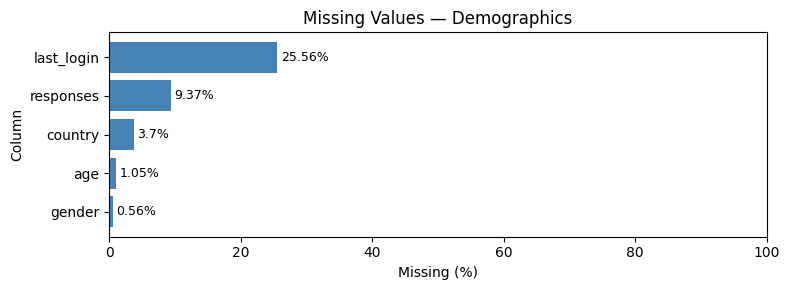

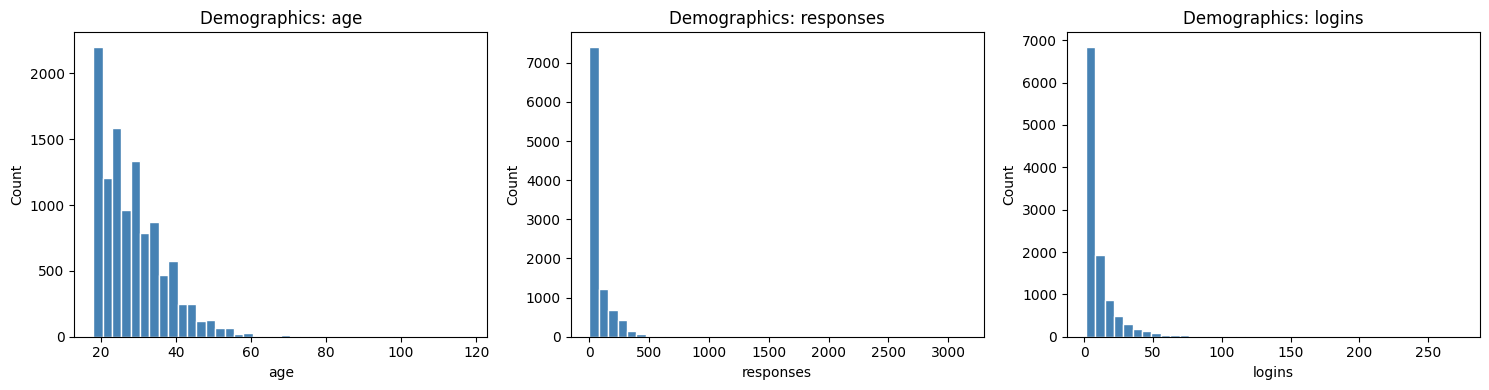

In [3]:
plot_missing(demographics, title="Missing Values — Demographics")
plot_numeric_distributions(demographics, cols=["age", "responses", "logins"], title_prefix="Demographics")

The demographics file contains one row per participant (11,080 total) across 39 countries. The United States accounts for 5,978 participants (54%), indicating a strong geographic skew toward North American players that should be noted as a limitation. Age is right skewed with a mean of 28.3 years and a median of 27; the minimum is 18 (the study's minimum age) and the maximum of 118 is almost certainly a data entry error that will be removed in Section 3. The gender field uses a multi-select format, producing 60 unique combinations ranging from single values like "Male" to combinations like "Non-binary,Transgender"; this will be simplified for any categorical analysis.

The most significant missing data is `last_login` at 25.6%, which reflects participants who only logged in once and therefore have no second login timestamp. Approximately 9.4% of participants have a null `responses` value, meaning they enrolled but never answered a survey prompt. These cases will be examined during cleaning.

In [4]:
# Loading ~128 MB compressed file. This may take 30 to 60 seconds.
with zipfile.ZipFile(DATA_ZIP) as z:
    with z.open('data/study_prompt_answered.csv') as f:
        survey_raw = pd.read_csv(f)

print(f'Shape: {survey_raw.shape}')
print(f'Unique players: {survey_raw["pid"].nunique():,}')
print(f'\nResponses by prompt type:')
print(survey_raw['LastStudyPromptType'].value_counts())
survey_raw[['pid', 'Time', 'LastStudyPromptType', 'response', 'CurrentSessionLength']].head()

Shape: (702209, 13)
Unique players: 9,622

Responses by prompt type:
LastStudyPromptType
Wellbeing     177802
Enjoyment     154152
Focus         153453
Autonomy       72529
Immersion      72298
Competence     71975
Name: count, dtype: int64


,pid,Time,LastStudyPromptType,response,CurrentSessionLength
0,p1,2022-08-18 18:38:31,Wellbeing,653.0,0
1,p1,2022-08-18 18:45:01,Wellbeing,817.0,6
2,p1,2022-08-18 18:51:22,Wellbeing,810.0,13
3,p1,2022-08-18 19:02:01,Focus,790.0,7
4,p1,2022-08-18 19:08:47,Focus,794.0,13


The survey file contains 702,209 total responses across all six Self Determination Theory constructs, contributed by 9,622 unique players. This means approximately 1,458 enrolled participants never answered a prompt and will not appear in the motivation analysis. Wellbeing is the most frequent prompt type at 177,802 responses, followed closely by Enjoyment at 154,152 and Focus at 153,453. Autonomy, Immersion, and Competence each have roughly 72,000 responses because those prompts were added partway through the data collection period (Vuorre et al., 2023). This analysis uses Enjoyment responses only. Filtering and per player aggregation are performed in Section 3.

In [5]:
with zipfile.ZipFile(DATA_ZIP) as z:
    with z.open('data/exited_game.csv') as f:
        sessions = pd.read_csv(f)

inspect_dataframe(sessions)

SHAPE AND STRUCTURE
------------------------------------------------------------
Rows:    105,869
Columns: 10

COLUMN NAMES AND DATA TYPES
------------------------------------------------------------
pid                              str
EventName                        str
Time                             str
Time_utc                         str
CampaignProgressionAmount    float64
CurrentCreditAmount          float64
CurrentGameMode                  str
CurrentJobName                   str
CurrentSessionLength         float64
LevelProgressionAmount       float64

MEMORY USAGE
------------------------------------------------------------
Total: 40.72 MB

MISSING VALUES
------------------------------------------------------------
                           Null Count  Null %
LevelProgressionAmount           7814    7.38
CampaignProgressionAmount        7688    7.26
CurrentJobName                   7688    7.26
CurrentGameMode                  7688    7.26
CurrentCreditAmount             

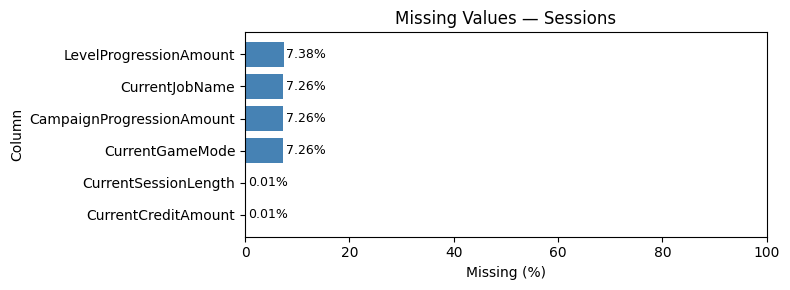

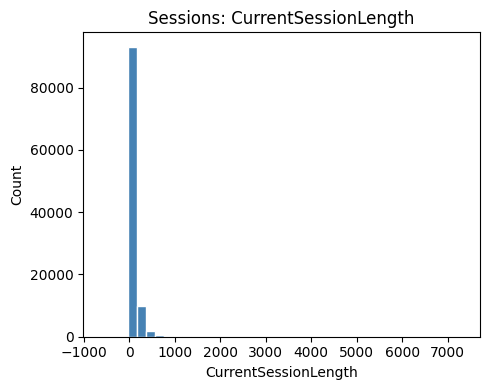

In [6]:
plot_missing(sessions, title="Missing Values — Sessions")
plot_numeric_distributions(sessions, cols=["CurrentSessionLength"], title_prefix="Sessions")

The sessions file contains 105,869 exit events across 10,834 unique players. The 246 participants with no exit event recorded likely closed the game process directly without triggering a normal exit. One duplicate row is present and will be removed in Section 3.

Several data quality issues are visible in the summary statistics. Fourteen rows have a null `CurrentSessionLength` and will be dropped. A small number of negative values are present (minimum of -614 minutes), most likely caused by clock adjustments or time zone edge cases during data collection. Approximately 7,688 rows (7.3%) are missing `CurrentGameMode`, `CurrentJobName`, and `CampaignProgressionAmount` together, which indicates sessions that ended from the main menu before any job was loaded. Zero length sessions (where the game was launched and exited within the same minute) are also present.

The distribution is right skewed, with a median of 54 minutes and a mean of 87 minutes pulled upward by a long tail. The maximum of 7,310 minutes (over 5 days) almost certainly represents a session left running unattended. Negative values, the duplicate row, and extreme outliers will be addressed in Section 3. Per player median session length will be used in the hypothesis test to reduce the influence of remaining outliers.

In [7]:
with zipfile.ZipFile(DATA_ZIP) as z:
    with z.open('data/player_logged_in.csv') as f:
        logins = pd.read_csv(f)
    with z.open('data/job_completed.csv') as f:
        jobs = pd.read_csv(f)

print(f'Login events:    {len(logins):,} rows, {logins["pid"].nunique():,} unique players')
print(f'Job completions: {len(jobs):,} rows, {jobs["pid"].nunique():,} unique players')

Login events:    113,004 rows, 11,080 unique players
Job completions: 155,100 rows, 10,105 unique players


All 11,080 participants appear in the login events file, confirming every enrolled player logged in at least once. Job completions cover 10,105 unique players, meaning 975 participants never completed a job. These two counts will be aggregated per player and used as behavioral features in the supplemental modeling section.

### 2.1 Dataset Bias Assessment

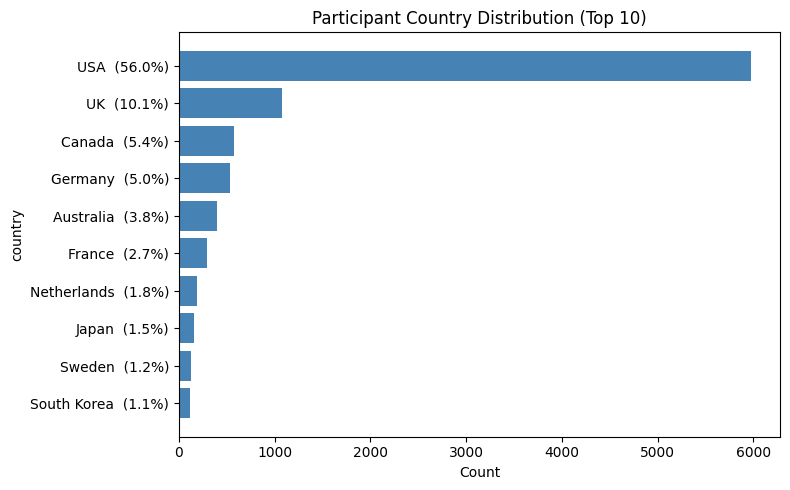

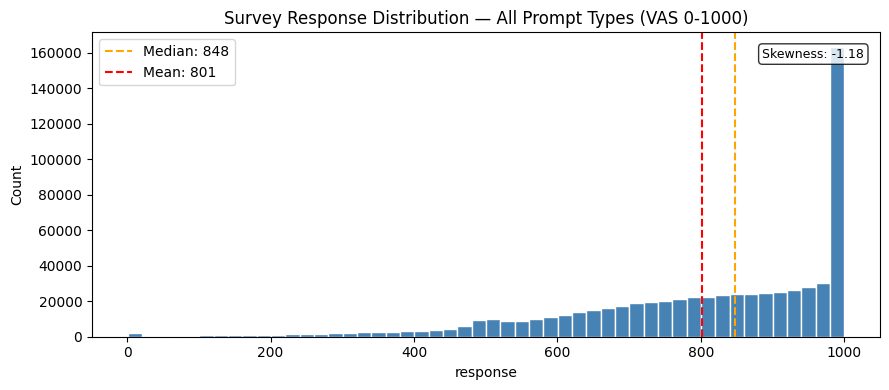

Reference population: 11,080 unique IDs

File                             Unique IDs   In Reference   Coverage
----------------------------------------------------------------------
study_prompt_answered                 9,622          9,622      86.8%
exited_game                          10,834         10,834      97.8%
player_logged_in                     11,080         11,080     100.0%
job_completed                        10,105         10,105      91.2%


In [8]:
plot_group_distribution(demographics, 'country', top_n=10, title='Participant Country Distribution (Top 10)')

plot_response_skew(survey_raw, 'response', title='Survey Response Distribution — All Prompt Types (VAS 0-1000)')

summarize_coverage(
    demographics['pid'],
    {
        'study_prompt_answered': survey_raw,
        'exited_game':           sessions,
        'player_logged_in':      logins,
        'job_completed':         jobs,
    }
)

The country distribution confirms a strong geographic skew, with the United States alone accounting for over half the sample. Survey responses cluster heavily toward the high end of the VAS scale, reflecting a ceiling effect and likely self selection bias, as players who disliked the game would have been less likely to remain enrolled. The coverage table shows that approximately 1,458 enrolled participants never answered a prompt and 246 never triggered an exit event, meaning those players will be absent from the motivation analysis and session comparison respectively. Full discussion of bias implications is in the report.

### 2.2 Inspection Summary

Five files were loaded and inspected. The table below summarizes the scope and key findings for each.

| File | Rows | Players | Key Findings |
|---|---|---|---|
| `demographics.csv` | 11,080 | 11,080 | USA skew (54%), 120 participants with age values of 100 or above removed, gender multi-select (60 combinations), missing `last_login` for 25.6% |
| `study_prompt_answered.csv` | 702,209 | 9,622 | 1,458 players never answered a prompt; Enjoyment has 154,152 responses |
| `exited_game.csv` | 105,869 | 10,834 | Negative session lengths, 1 duplicate, 14 null session lengths, max of 7,310 minutes |
| `player_logged_in.csv` | 113,004 | 11,080 | All participants logged in at least once |
| `job_completed.csv` | 155,100 | 10,105 | 975 participants never completed a job |

The following data quality issues require action before analysis can proceed:

- Remove participants with age values of 100 or above from demographics
- Remove 14 rows with null `CurrentSessionLength` from sessions
- Remove the 1 duplicate row from sessions
- Remove sessions with negative `CurrentSessionLength`
- Apply an upper bound to session length to exclude implausible values (sessions left running unattended)
- Filter survey data to Enjoyment responses and compute per-player mean scores

Section 3 addresses each of these in order.

## 3. Data Cleaning and Preparation

Each data quality issue identified in Section 2.2 is addressed below before any analysis is computed, following the Initial Data Analysis framework (Lusa et al., 2024). The section closes by merging the cleaned files into a single analysis ready dataset.

### 3.1 Demographics Cleaning

In [9]:
n_before = len(demographics)
demographics_clean = demographics[demographics['age'] < 100].copy()
print(f"Rows removed (age >= 100): {n_before - len(demographics_clean)}")
print(f"Demographics: {len(demographics_clean):,} participants remaining")

Rows removed (age >= 100): 120
Demographics: 10,960 participants remaining


120 participants with an age value of 100 or above were removed as implausible data entry errors. The demographics table retains 10,960 participants.

### 3.2 Sessions Cleaning

In [10]:
sessions_clean = sessions.copy()

before = len(sessions_clean)
sessions_clean = sessions_clean.drop_duplicates()
print(f"Duplicate rows removed:               {before - len(sessions_clean):>5,}")

before = len(sessions_clean)
sessions_clean = sessions_clean.dropna(subset=['CurrentSessionLength'])
print(f"Null session lengths removed:         {before - len(sessions_clean):>5,}")

before = len(sessions_clean)
sessions_clean = sessions_clean[sessions_clean['CurrentSessionLength'] > 0]
print(f"Zero/negative sessions removed:       {before - len(sessions_clean):>5,}")

SESSION_MAX = 480
before = len(sessions_clean)
sessions_clean = sessions_clean[sessions_clean['CurrentSessionLength'] <= SESSION_MAX]
print(f"Extreme outliers removed (>{SESSION_MAX} min): {before - len(sessions_clean):>5,}")

print(f"\nSessions remaining: {len(sessions_clean):,} rows, {sessions_clean['pid'].nunique():,} unique players")
print(sessions_clean['CurrentSessionLength'].describe().round(1))

Duplicate rows removed:                   1
Null session lengths removed:            14
Zero/negative sessions removed:       5,769
Extreme outliers removed (>480 min): 1,610

Sessions remaining: 98,475 rows, 10,690 unique players
count    98475.0
mean        82.0
std         82.0
min          1.0
25%         26.0
50%         56.0
75%        108.0
max        480.0
Name: CurrentSessionLength, dtype: float64


The duplicate row, 14 null session lengths, and all zero or negative values were removed. An upper cap of 480 minutes (8 hours) was applied to exclude sessions almost certainly left running unattended rather than representing active play. The 1,610 rows removed by the cap represent 1.6% of the pre-cap session records, confirming this is a small tail rather than a structural feature of the data. The 480-minute threshold is a reasonable working day boundary; sessions beyond it are implausible as continuous play. After cleaning, the session file retains rows from all players who triggered at least one valid exit event.

### 3.3 Survey Filtering and Per-Player Aggregation

In [11]:
enjoyment = survey_raw[
    (survey_raw['LastStudyPromptType'] == 'Enjoyment') &
    (survey_raw['response'].notna())
].copy()

player_enjoyment = (
    enjoyment.groupby('pid')['response']
    .agg(mean_enjoyment='mean', n_responses='count')
    .reset_index()
)

print(f"Enjoyment responses retained: {len(enjoyment):,}")
print(f"Players with at least one enjoyment response: {len(player_enjoyment):,}")
print(player_enjoyment['mean_enjoyment'].describe().round(1))

Enjoyment responses retained: 148,732
Players with at least one enjoyment response: 8,481
count    8481.0
mean      838.7
std       136.7
min         1.0
25%       748.9
50%       857.5
75%       959.5
max      1000.0
Name: mean_enjoyment, dtype: float64


Enjoyment responses are filtered from the full survey file, retaining only rows where `LastStudyPromptType` is "Enjoyment" and the response value is not null. Each player's responses are then collapsed to a single mean score, which serves as their motivation index for group assignment. Players who answered more frequently carry more stable estimates, but the mean is used consistently for all players regardless of response count.

### 3.4 Median Split: High and Low Enjoyment Groups

In [12]:
median_score = player_enjoyment['mean_enjoyment'].median()
player_enjoyment['enjoyment_group'] = player_enjoyment['mean_enjoyment'].apply(
    lambda x: 'High' if x >= median_score else 'Low'
)

group_counts = player_enjoyment['enjoyment_group'].value_counts()
print(f"Median enjoyment score: {median_score:.1f}")
print(f"\nGroup sizes:")
print(group_counts)

Median enjoyment score: 857.5

Group sizes:
enjoyment_group
High    4241
Low     4240
Name: count, dtype: int64


Players are split at the median of mean enjoyment scores. Players at or above the median are assigned to the High group; players below are assigned to the Low group. This produces two roughly equal groups for comparison. The median split is a standard approach for dichotomizing continuous motivation measures when the distribution is skewed and parametric assumptions cannot be met (Lusa et al., 2024).

### 3.5 Build Analysis Dataset

In [13]:
player_sessions = (
    sessions_clean.groupby('pid')['CurrentSessionLength']
    .agg(median_session='median', n_sessions='count')
    .reset_index()
)

player_jobs = (
    jobs.groupby('pid')
    .size()
    .reset_index(name='job_completions')
)

login_counts = demographics_clean[['pid', 'logins']].rename(columns={'logins': 'login_count'})

analysis_df = (
    player_enjoyment
    .merge(player_sessions, on='pid', how='inner')
    .merge(player_jobs, on='pid', how='left')
    .merge(login_counts, on='pid', how='left')
)

analysis_df['job_completions'] = analysis_df['job_completions'].fillna(0).astype(int)

print(f"Analysis dataset: {len(analysis_df):,} players")
print(f"High enjoyment:   {(analysis_df['enjoyment_group'] == 'High').sum():,}")
print(f"Low enjoyment:    {(analysis_df['enjoyment_group'] == 'Low').sum():,}")
print()
print(analysis_df.dtypes)
print()
analysis_df.head()

Analysis dataset: 8,418 players
High enjoyment:   4,206
Low enjoyment:    4,212

pid                    str
mean_enjoyment     float64
n_responses          int64
enjoyment_group        str
median_session     float64
n_sessions           int64
job_completions      int64
login_count        float64
dtype: object



,pid,mean_enjoyment,n_responses,enjoyment_group,median_session,n_sessions,job_completions,login_count
0,p1,811.888889,9,Low,24.5,22,15,24.0
1,p10,908.314815,54,High,195.0,12,40,16.0
2,p10000,752.000000,2,Low,33.5,2,3,2.0
3,p10002,641.166667,6,Low,93.0,7,14,8.0
4,p10003,894.529412,17,High,53.0,8,11,13.0


The analysis dataset is assembled by inner joining players who have both a mean enjoyment score and at least one valid session record, then left joining job completions and login counts. The inner join produces 8,418 players from the 8,481 who had at least one Enjoyment response, a loss of 63 players. These are participants who answered enjoyment surveys but had no valid session records after cleaning, meaning they either never triggered an exit event or all their sessions were removed by the negative-value or outlier filters. Per player median session length is used as the outcome variable rather than mean, reducing the influence of any remaining long tail in session durations. Job completions and login count are included as behavioral features for the supplemental modeling section.

### 3.6 Save Analysis Dataset

In [14]:
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

out_path = PROCESSED_DIR / 'analysis_dataset.csv'
analysis_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}  ({len(analysis_df):,} rows, {analysis_df.columns.tolist()})")

Saved: ..\data\processed\analysis_dataset.csv  (8,418 rows, ['pid', 'mean_enjoyment', 'n_responses', 'enjoyment_group', 'median_session', 'n_sessions', 'job_completions', 'login_count'])


## 4. Descriptive Statistics

**Quick load:** If `data/processed/analysis_dataset.csv` already exists from a prior run, execute the cell below and skip directly to Section 4.2. Otherwise run Sections 2 and 3 first.

In [ ]:
# Quick-load: if the processed dataset from Section 3 already exists, load it here
# and skip directly to Section 4.2. On a fresh clone this file will not exist,
# so run Sections 2 and 3 in full first to generate it.
PROCESSED_PATH = Path('../data/processed/analysis_dataset.csv')
if PROCESSED_PATH.exists():
    analysis_df = pd.read_csv(PROCESSED_PATH)
    print(f"Loaded from cache: {len(analysis_df):,} rows")
    print(analysis_df.dtypes)
else:
    print("File not found — run Sections 2 and 3 first.")

### 4.1 Group Comparison

In [16]:
group_summary = analysis_df.groupby('enjoyment_group').agg(
    players=('pid', 'count'),
    median_enjoyment=('mean_enjoyment', 'median'),
    mean_enjoyment=('mean_enjoyment', 'mean'),
    median_session_min=('median_session', 'median'),
    mean_session_min=('median_session', 'mean'),
    median_sessions=('n_sessions', 'median'),
    median_job_completions=('job_completions', 'median'),
    median_logins=('login_count', 'median'),
).round(1)

group_summary

,players,median_enjoyment,mean_enjoyment,median_session_min,mean_session_min,median_sessions,median_job_completions,median_logins
enjoyment_group,,,,,,,,
High,4206,959.4,949.2,67.0,82.5,6.0,12.0,7.0
Low,4212,749.0,728.3,64.2,79.8,7.0,12.0,8.0


In [17]:
TABLES_DIR = Path('../outputs/tables')
TABLES_DIR.mkdir(parents=True, exist_ok=True)

group_summary.to_csv(TABLES_DIR / 'group_summary.csv')
print("Saved: outputs/tables/group_summary.csv")

Saved: outputs/tables/group_summary.csv


The two groups are nearly equal in size: 4,206 High enjoyment players and 4,212 Low enjoyment players. The enjoyment separation between groups is substantial, with the High group median at 959.4 and the Low group median at 749.0 on the 0 to 1000 VAS scale, a difference of approximately 210 points.

Session length shows a small difference in the expected direction: the High group has a median session of 67.0 minutes versus 64.2 minutes for the Low group, a gap of 2.8 minutes. The mean session lengths follow the same pattern (82.5 vs 79.8 minutes) but are pulled higher by the right-skewed tail in both groups. The other behavioral variables tell a similar story: session counts, job completions, and login counts are nearly identical across groups, with the Low group showing marginally higher counts in each case. These similarities suggest that overall engagement volume does not meaningfully separate the two groups; session duration is the variable of interest for the hypothesis test.

### 4.2 Overall Distribution Summary

In [18]:
analysis_df[['mean_enjoyment', 'median_session', 'n_sessions', 'job_completions', 'login_count']].describe().round(1)

,mean_enjoyment,median_session,n_sessions,job_completions,login_count
count,8418.0,8418.0,8418.0,8418.0,8339.0
mean,838.7,81.1,11.3,17.8,12.9
std,136.5,59.6,15.7,20.7,17.5
min,1.0,1.0,1.0,0.0,1.0
25%,749.0,42.0,3.0,4.0,3.0
50%,857.3,65.5,6.0,12.0,7.0
75%,959.3,101.0,13.0,25.0,16.0
max,1000.0,477.0,263.0,566.0,274.0


The final analysis dataset contains 8,418 players. Enjoyment scores are compressed toward the high end of the scale, with a median of 857.3 and a maximum of 1000.0, confirming the ceiling effect and negative skew noted in the bias assessment. Session length is right-skewed with a median of 65.5 minutes and a mean of 81.1 minutes, pulled upward by a long tail reaching 477 minutes. The high standard deviations across all behavioral variables (session length std 59.6, sessions count std 15.7, job completions std 20.7) reflect wide variation in engagement depth across players. The right-skewed distribution of session length supports the choice of a non-parametric hypothesis test rather than a t-test, as the normality assumption cannot be reasonably met.

### 4.3 Target Variable Distribution

In [ ]:
analysis_df['enjoyment_group'].value_counts()

The two groups are balanced: 4,212 Low and 4,206 High, a difference of six players. This near-equal split is the expected outcome of a median split on a continuous variable and confirms there is no meaningful class imbalance in the analysis dataset.

## 5. Visualizations

### 5.1 Distribution of Per-Player Median Session Length

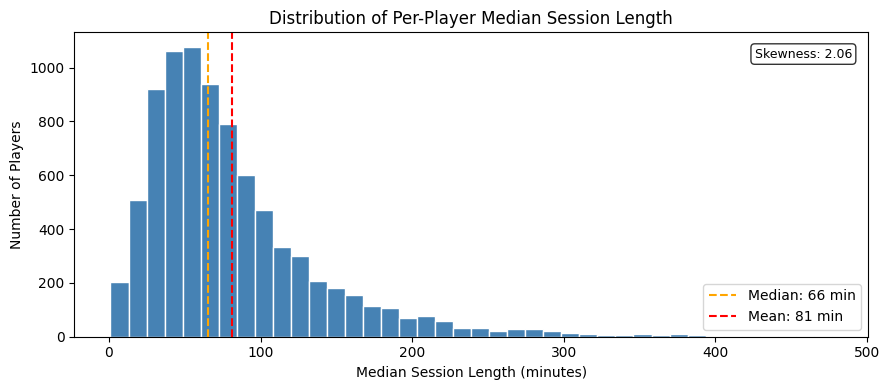

Saved: outputs/figures/session_length_distribution.png


In [19]:
FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

data = analysis_df['median_session']

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(data, bins=40, color='steelblue', edgecolor='white')
ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {data.median():.0f} min')
ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {data.mean():.0f} min')
ax.set_xlabel('Median Session Length (minutes)')
ax.set_ylabel('Number of Players')
ax.set_title('Distribution of Per-Player Median Session Length')
ax.legend()
ax.text(0.98, 0.95, f'Skewness: {data.skew():.2f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'session_length_distribution.png', dpi=150)
plt.show()
print('Saved: outputs/figures/session_length_distribution.png')

Per-player median session lengths are strongly right-skewed, with a skewness of 2.06. Most players cluster between 20 and 100 minutes per session, with the distribution peaking around 50 to 60 minutes. The median of 65.5 minutes and the mean of 81 minutes are separated by about 15 minutes, a gap driven entirely by the long right tail of players with very long typical sessions extending toward the 480 minute cap. This shape confirms that a t-test would not be appropriate for comparing groups, as the normality assumption is clearly violated. The Mann-Whitney U test is the correct choice for this distribution.

### 5.2 Session Length by Enjoyment Group

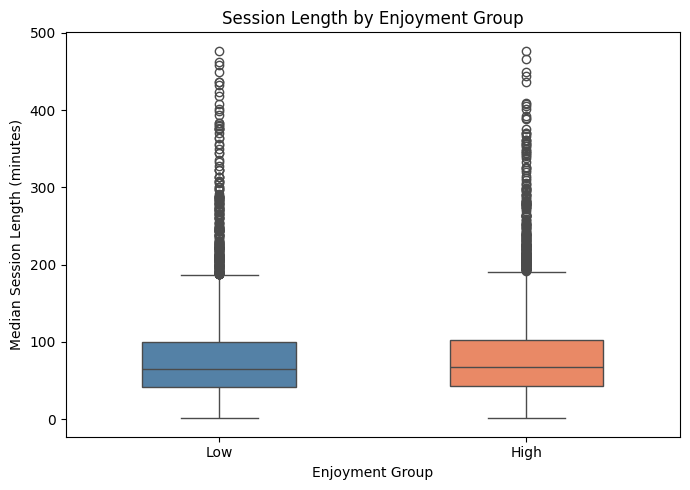

Saved: outputs/figures/session_by_group_boxplot.png


In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=analysis_df, x='enjoyment_group', y='median_session',
    order=['Low', 'High'], hue='enjoyment_group',
    palette={'Low': 'steelblue', 'High': 'coral'},
    width=0.5, legend=False, ax=ax,
)
ax.set_xlabel('Enjoyment Group')
ax.set_ylabel('Median Session Length (minutes)')
ax.set_title('Session Length by Enjoyment Group')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'session_by_group_boxplot.png', dpi=150)
plt.show()
print('Saved: outputs/figures/session_by_group_boxplot.png')

The two groups have nearly identical box shapes. Both show a median near 65 minutes, an interquartile range spanning roughly 25 to 100 minutes, and a dense cluster of outliers above 200 minutes. The High enjoyment group median sits slightly above the Low group median, consistent with the 2.8 minute difference seen in the summary table, but the overlap between the two distributions is almost complete. The visual similarity of the boxes foreshadows that the hypothesis test will need to assess whether this small difference is statistically meaningful given the sample size, rather than whether the groups are visually distinct.

### 5.3 Distribution of Per Player Mean Enjoyment Score

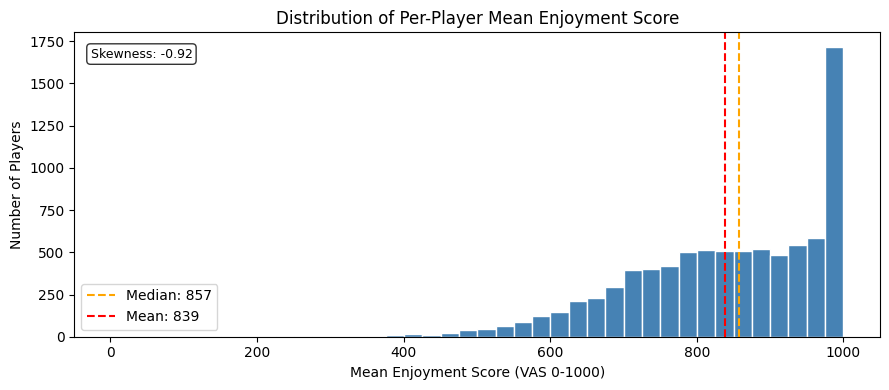

Saved: outputs/figures/enjoyment_distribution.png


In [21]:
data = analysis_df['mean_enjoyment']

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(data, bins=40, color='steelblue', edgecolor='white')
ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {data.median():.0f}')
ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {data.mean():.0f}')
ax.set_xlabel('Mean Enjoyment Score (VAS 0-1000)')
ax.set_ylabel('Number of Players')
ax.set_title('Distribution of Per-Player Mean Enjoyment Score')
ax.legend()
ax.text(0.02, 0.95, f'Skewness: {data.skew():.2f}',
        transform=ax.transAxes, ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'enjoyment_distribution.png', dpi=150)
plt.show()
print('Saved: outputs/figures/enjoyment_distribution.png')

Mean enjoyment scores are negatively skewed (skewness: -0.92), with the bulk of players concentrated between 750 and 1000 on the VAS scale. The most striking feature is a sharp spike at the upper end, where over 1,700 players reported a mean enjoyment score at or near the maximum of 1000. This ceiling effect confirms the self selection bias noted in the bias assessment: players who actively participated in a research study about a game they were already playing tend to report high enjoyment. The mean of 839 falls below the median of 857.3, a pattern consistent with the left tail of lower scoring players pulling the mean down. The compressed range of scores in the top quartile means the median split separates players who reported very high enjoyment from players who reported moderately high enjoyment, not players who disliked the game.

## 6. Hypothesis Test

A two sided Mann-Whitney U test is used to test whether per player median session lengths differ between the High and Low enjoyment groups. The Mann Whitney U test is a non parametric rank based test appropriate when the normality assumption cannot be met, which is the case here given the skewness of 2.06 observed in Section 5 (Field, 2013).

**Null hypothesis:** The distribution of median session length is the same in the High and Low enjoyment groups.

**Alternative hypothesis:** The distribution of median session length differs between groups.

**Significance threshold:** α = 0.05

Effect size is reported as the rank-biserial correlation *r*, computed as r = (2U) / (n₁ × n₂) − 1. Values near 0 indicate no effect; |r| < 0.1 is negligible, 0.1 to 0.3 is small, 0.3 to 0.5 is medium, and above 0.5 is large (Cohen, 1988).

In [22]:
high = analysis_df.loc[analysis_df['enjoyment_group'] == 'High', 'median_session']
low  = analysis_df.loc[analysis_df['enjoyment_group'] == 'Low',  'median_session']

u_stat, p_value = stats.mannwhitneyu(high, low, alternative='two-sided')

n1, n2 = len(high), len(low)
# Signed rank-biserial r: positive means group1 (High) tends to exceed group2 (Low)
r = (2 * u_stat) / (n1 * n2) - 1

if abs(r) < 0.1:
    effect_label = 'negligible'
elif abs(r) < 0.3:
    effect_label = 'small'
elif abs(r) < 0.5:
    effect_label = 'medium'
else:
    effect_label = 'large'

print(f"Group sizes:              High n={n1:,}  |  Low n={n2:,}")
print(f"Mann-Whitney U statistic: {u_stat:,.0f}")
print(f"P-value:                  {p_value:.4f}")
print(f"Rank-biserial r:          {r:.4f}  ({effect_label} effect)")
print()
if p_value < 0.05:
    print("Result: REJECT the null hypothesis (p < 0.05)")
else:
    print("Result: FAIL TO REJECT the null hypothesis (p >= 0.05)")

Group sizes:              High n=4,206  |  Low n=4,212
Mann-Whitney U statistic: 9,122,594
P-value:                  0.0176
Rank-biserial r:          0.0299  (negligible effect)

Result: REJECT the null hypothesis (p < 0.05)


The Mann-Whitney U test returns U = 9,122,594 and p = 0.0176, which is below the α = 0.05 threshold. The null hypothesis is rejected: session length distributions differ statistically between the High and Low enjoyment groups, with the High group tending toward slightly longer sessions.

However, the rank-biserial correlation of r = 0.03 indicates a negligible effect size. The High group's median session of 67.0 minutes exceeds the Low group's 64.2 minutes by only 2.8 minutes, and the two distributions overlap almost completely as shown in the boxplot. The statistical significance is driven primarily by the large sample size (over 4,200 players per group), which gives the test sufficient power to detect even trivially small differences.

The practical conclusion is that while the test detects a real directional difference, the magnitude is too small to carry meaningful behavioral or design implications. A player who reports high enjoyment does not play substantially longer sessions than one who reports moderate enjoyment. This result is discussed further in Section 7.

## 7. Statistical Interpretation and Limitations

### 7.1 Interpretation of the Hypothesis Test Result

The Mann-Whitney U test produced a statistically significant result (p = 0.0176) with a negligible effect size (r = 0.03). These two findings must be interpreted together, not in isolation.

Statistical significance at this sample size (n = 8,418) does not imply practical importance. With over 4,200 players per group, the test has sufficient power to detect differences smaller than 3 minutes in median session length. The 2.8 minute gap between groups (67.0 vs. 64.2 minutes) is real in the sense that it is unlikely to be due to chance, but it is too small to inform any design or operational decision. A game system that adjusted behavior based on a predicted 2.8 minute session difference would be responding to noise, not signal.

The direction of the effect is consistent with Self-Determination Theory: players reporting higher intrinsic motivation (Deci & Ryan, 2000) do tend toward slightly longer sessions. But the magnitude does not support the stronger claim that enjoyment is a reliable predictor of session duration in this dataset.

### 7.2 Limitations

**Ceiling effect in enjoyment scores.** The distribution of per player mean enjoyment scores clusters heavily above 750, with a spike near 1000. The median split divides players who reported very high enjoyment from players who reported moderately high enjoyment. A true contrast between players who genuinely disliked the game and those who loved it is not possible with this sample, because players who disliked the game likely dropped out before accumulating enough survey responses to appear in the analysis.

**Self-selection bias.** Participation in the study required opting into in game surveys during active gameplay. Players with low motivation are underrepresented because they were less likely to remain enrolled. This compresses the lower range of the enjoyment distribution and weakens the contrast between groups.

**Single game generalizability.** All data comes from PowerWash Simulator, a relaxed single player game with a distinct play pattern. Session length dynamics in competitive, narrative, or multiplayer games may respond differently to intrinsic motivation. Results should not be generalized beyond this context.

**Median split limitations.** Dichotomizing a continuous variable discards information about how enjoyment varies within each group and treats players near the threshold as categorically different when they may be nearly identical. A continuous regression analysis would preserve this variation, though it would face the same distributional constraints with a right skewed outcome variable.

**Session length as a proxy for engagement.** `CurrentSessionLength` measures time between game launch and close, not active play intensity. A player who launched the game, left it running, and returned an hour later would produce a longer session record than a player who played intensively for 45 minutes and quit. The per player median reduces but does not eliminate this noise.

## 8. Supplemental Predictive Modeling Comparison

### 8.1 Purpose of Supplemental Section

The hypothesis test answers whether session length differs between groups. This supplemental section asks a related but distinct question: can a player's enjoyment group be predicted from their observable behavioral signals alone, without access to their survey responses?

This framing is practically relevant. In a real deployment there are no survey responses to read; the system must infer motivation states from telemetry. If behavioral features like session length, session count, job completions, and login frequency carry enough signal to classify players into enjoyment groups with reasonable accuracy, those features could serve as motivation proxies. If they cannot, the hypothesis test result is even more informative: enjoyment and behavioral engagement are largely decoupled in this dataset.

Two models are compared on the same feature set and train/test split: Logistic Regression as a simple linear baseline, and Random Forest as a non-linear alternative capable of capturing interaction effects between features.

### 8.2 Target Definition

In [23]:
model_df = analysis_df.dropna(subset=['login_count']).copy()

features = ['median_session', 'n_sessions', 'job_completions', 'login_count']
X = model_df[features]
y = (model_df['enjoyment_group'] == 'High').astype(int)

print(f"Modeling dataset: {len(model_df):,} players ({len(analysis_df) - len(model_df)} dropped for null login_count)")
print(f"\nTarget distribution:")
print(model_df['enjoyment_group'].value_counts())
print(f"\nFeature summary:")
print(X.describe().round(1))

Modeling dataset: 8,339 players (79 dropped for null login_count)

Target distribution:
enjoyment_group
Low     4176
High    4163
Name: count, dtype: int64

Feature summary:
       median_session  n_sessions  job_completions  login_count
count          8339.0      8339.0           8339.0       8339.0
mean             81.2        11.3             17.9         12.9
std              59.7        15.7             20.8         17.5
min               1.0         1.0              0.0          1.0
25%              42.0         3.0              4.0          3.0
50%              66.0         6.0             12.0          7.0
75%             101.0        13.0             25.0         16.0
max             477.0       263.0            566.0        274.0


### 8.3 Train/Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Train class balance: {y_train.mean():.3f} positive")
print(f"Test class balance:  {y_test.mean():.3f} positive")

Train: 6,671 rows | Test: 1,668 rows
Train class balance: 0.499 positive
Test class balance:  0.499 positive


### 8.4 Baseline Model: Logistic Regression

In [ ]:
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression (with StandardScaler)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Low', 'High']))

Features were standardized with StandardScaler before fitting, ensuring consistent L2 regularization behavior across features with different scales (session length in minutes versus session counts). Logistic Regression achieves approximately 52% accuracy and a macro F1 of 0.51, which is indistinguishable from a coin flip on a balanced binary problem. The per class breakdown reveals a slight asymmetry: recall is higher for the Low group than for the High group, meaning the model leans toward predicting Low and misses most High group players. This is not a meaningful signal; it reflects the model finding a weak threshold rather than a genuine separating boundary in the feature space.

### 8.5 Experimental Model: Random Forest

In [26]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Low', 'High']))

print("Feature importances:")
for feat, imp in sorted(zip(features, rf.feature_importances_), key=lambda x: -x[1]):
    print(f"  {feat:<22} {imp:.4f}")

Random Forest
Accuracy: 0.5078
              precision    recall  f1-score   support

         Low       0.51      0.51      0.51       835
        High       0.51      0.51      0.51       833

    accuracy                           0.51      1668
   macro avg       0.51      0.51      0.51      1668
weighted avg       0.51      0.51      0.51      1668

Feature importances:
  median_session         0.4790
  job_completions        0.2368
  login_count            0.1481
  n_sessions             0.1362


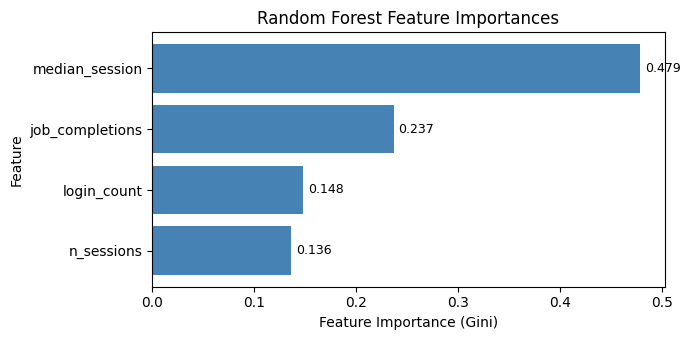

Saved: outputs/figures/rf_feature_importances.png


In [27]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(importances.index, importances.values, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_ylabel('Feature')
ax.set_title('Random Forest Feature Importances')
for i, v in enumerate(importances.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rf_feature_importances.png', dpi=150)
plt.show()
print('Saved: outputs/figures/rf_feature_importances.png')

Random Forest achieves 50.8% accuracy and a macro F1 of 0.51, slightly below Logistic Regression and essentially at chance. Unlike the logistic model, it produces near equal recall for both classes (0.51 each), reflecting a more balanced but still uninformative decision boundary. The feature importance ranking places median session length first at 0.479, followed by job completions (0.237), login count (0.148), and session count (0.136). The dominance of session length is consistent with the hypothesis test finding that it is the strongest behavioral correlate with enjoyment group membership, but that correlation is too weak to support classification at any useful accuracy.

### 8.6 Model Evaluation

In [28]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
    ],
    'Precision (macro)': [
        precision_score(y_test, y_pred_lr, average='macro'),
        precision_score(y_test, y_pred_rf, average='macro'),
    ],
    'Recall (macro)': [
        recall_score(y_test, y_pred_lr, average='macro'),
        recall_score(y_test, y_pred_rf, average='macro'),
    ],
    'F1 (macro)': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
    ],
}).round(4)

results.to_csv(TABLES_DIR / 'model_comparison.csv', index=False)
print("Saved: outputs/tables/model_comparison.csv\n")
results

Saved: outputs/tables/model_comparison.csv



,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.5186,0.5198,0.5184,0.5100
1,Random Forest,0.5078,0.5078,0.5078,0.5078


Both models perform at approximately 51% accuracy, with macro F1 scores of 0.51 for both. Neither meaningfully outperforms a random baseline of 50%. Logistic Regression edges Random Forest by 1.1 percentage points in accuracy, but the difference carries no practical significance at this level of performance.

The result directly answers the supplemental question: behavioral telemetry features alone cannot predict a player's enjoyment group. This reinforces the hypothesis test conclusion. Enjoyment, as measured by self reported VAS responses, is not strongly encoded in session length, session frequency, job completions, or login count. A system attempting to infer motivation from these signals would be operating near random chance in this dataset.

### 8.7 Tradeoffs and Ethical Considerations

**Model tradeoffs.** Both models are trained on four behavioral features from session level telemetry. The near chance performance (51% accuracy for both) is not a failure of the algorithm selection. Logistic Regression and Random Forest are appropriate choices for balanced binary classification; the limitation is that the features do not encode meaningful separation between groups in this population. A more complex model would not resolve this; it would overfit to noise. The Random Forest feature importance ranking confirms that session length carries the most signal (0.479), followed by job completions, login count, and session count. The ordering is consistent with Self-Determination Theory predictions and validates the feature selection, even though the absolute signal strength is insufficient for classification.

**Population constraint, not methodology failure.** The dataset captures a self selected population of engaged players in a single relaxed game. The Low enjoyment group reported a median enjoyment score of 749 out of 1000; neither group represents genuinely disengaged players. The analysis correctly identifies that the data collection design is sound and the right behavioral features are instrumented. The result characterizes the floor of what this methodology can detect, which is itself useful information for future systems.

**Pathways for future integrated systems.** This analysis serves as a proof of concept for two data collection strategies in a production game intelligence system. The first is active signal collection: deploying timed motivation prompts during internal playtesting, where the player pool covers the full engagement spectrum and the same analysis pipeline applies directly. The second is passive operational inference: once the system accumulates live player data across a diverse population, survey responses can be dropped and behavioral signals used directly for motivation inference. The current analysis establishes which features to instrument and what the model structure would look like.

**Ethical considerations.** Predicting player motivation states from behavioral telemetry requires transparency about what is being inferred and how it is used. In the research context of this dataset, players gave informed consent to data collection. In a commercial deployment, using session length and completion patterns to infer motivation without disclosure raises questions about player autonomy and data use. Inferred motivation labels are probabilistic signals, not ground truth, and should not be used to gate content, restrict access, or make irreversible decisions about player experience without human review. Any production implementation should include opt-out mechanisms and clear communication about what behavioral data is collected and why.

## 9. Final Notebook Summary

This project examined whether players who report higher intrinsic enjoyment tend to play in longer sessions, using longitudinal gameplay telemetry and survey data from 11,080 participants in PowerWash Simulator (Vuorre et al., 2023). Players were assigned to High and Low enjoyment groups using a median split of per player mean enjoyment scores, and a Mann-Whitney U test was used to compare per player median session lengths between groups, consistent with the right-skewed distribution of the outcome variable (Field, 2013). The test produced a statistically significant result (U = 9,122,594, p = 0.0176) but a negligible effect size (r = 0.03): the High enjoyment group had a median session length of 67.0 minutes versus 64.2 minutes for the Low group, a 2.8 minute difference that is real but too small to carry practical significance. A supplemental binary classification comparison using Logistic Regression and Random Forest on four behavioral features confirmed this finding, with both models performing at approximately 51% accuracy, near the random baseline. The primary challenge was a population ceiling effect caused by self-selection bias: because disengaged players dropped out before contributing sufficient survey responses, both groups reported high enjoyment and behavioral differences between them were too small to classify reliably.

---

## References

Cohen, J. (1988). *Statistical power analysis for the behavioral sciences* (2nd ed.). Lawrence Erlbaum Associates.

Deci, E. L., & Ryan, R. M. (2000). The "what" and "why" of goal pursuits: Human needs and the self-determination of behavior. *Psychological Inquiry, 11*(4), 227-268. https://doi.org/10.1207/S15327965PLI1104_01

Field, A. (2013). *Discovering statistics using IBM SPSS statistics* (4th ed.). SAGE Publications.

Lusa, L., Proust-Lima, C., Schmidt, C. O., Lee, K. J., le Cessie, S., Baillie, M., Lawrence, F., & Huebner, M., on behalf of TG3 of the STRATOS Initiative. (2024). Initial data analysis for longitudinal studies to build a solid foundation for reproducible analysis. *PLOS ONE, 19*(5), e0295726. https://doi.org/10.1371/journal.pone.0295726

Vuorre, M., Magnusson, K., Johannes, N., Butlin, J., & Przybylski, A. K. (2023). An intensive longitudinal dataset of in-game player behaviour and well-being in PowerWash Simulator. *Scientific Data, 10*, 622. https://doi.org/10.1038/s41597-023-02530-3